1. 생성 모델
    - 분류모델과 생성모델의 차이
    - 생성모델의 분류
        - AE
        - VAE
        - GAN
            - 구조와 장단점
        - 확산모델
            - 순확산과 역확산
2. AI 최적화
    - 전이학습
        - 전이학습의 개념과 분류
        - Pre-Training과 Fine-tuning
    - AI Alignment
        - RLHF
    - 프롬프트 엔지니어링


# 1. 생성 모델의 개념
- 개념: 주어진 학습 데이터를 학습해, **학습 데이터의 분포를 따르는 유사한 데이터를 생성하는 모델**

## 1.1 분류 모델 vs 생성 모델
- 분류 모델: 본 적 없는 이상한 데이터(예: 외계인 그림)가 들어와도, 모델은 기존에 배운 라벨(고양이 혹은 개) 중 하나로 결론 내려야 함
- 생성 모델: 불합리하거나 이상한 입력에 대해서는 "이건 세상에 존재할 확률이 거의 0이야"라고 판단하며 거부할 수 있음
<br> ->  데이터가 가진 '특징의 분포'를 배워서 그 분포 내에 존재할 법한 **'새로운 데이터'를 샘플링**하는 과정

생성모델 학습 목표: P(X) 모델링 (세상에 존재할 법한 데이터 X 자체의 확률 분포 파악)

- 예시: 
	- 분류모델: "이 그림은 고양이야, 저 그림은 개야"라는 정답 정보를 토대로 둘 사이의 경계선을 긋는 데 집중
	- 생성모델: 고양이의 생김새, 털의 질감, 귀의 모양 등 고양이의 본질적인 특성을 학습함. <br>원리를 깨우쳤기 때문에 "고양이 한 마리 그려봐"라고 했을 때 새로운 그림을 그려낼 수 있음

## 1.2 생성 모델의 분류
- "확률 밀도를 직접 계산할 수 있는가?"에 따라 **명시적 모델**과 **암시적 모델**로 분류됨
	- 명시적 모델: 확률밀도 계산 가능. 재료 함량(P(X))이 정확히 적힌 레시피 북과 같다
	- 암시적 모델: 확률밀도 계산 불가능. 재료 함량(확률)은 모르겠고, 주문하면 똑같은 맛의 요리(샘플)를 내어주는 요리사

- 왜 확률밀도?: 생성모델의 목표는 데이터가 어떻게 생성되는지 배우는 것->수학적으로는 P(x)로 표현. P(x) : 데이터 x가 나타날 확률. 
	

- 명시적 확률밀도 모델: 모델이 데이터의 확률 분포인 P(X)의 값을 **직접적으로 수치화하여 출력**할 수 있는 모델
	- 정확히 계산 가능한 모델: 수학적으로 확률 값을 정확하게 계산할 수 있음. 예시) 자기회귀 모델
	- 근사적 밀도 모델: 확률값을 정확히 구하기 복잡해서 그 근삿값이나 하한선을 계산. 예시) **VAE**

- 암시적 확률밀도 모델: 데이터의 확률 분포 P(X)가 무엇인지 수치로 알려주지는 않지만, 그 분포를 따르는 **데이터를 생성(Sampling)할 수는 있는** 모델
	- 직접 샘플링: 신경망을 한 번 통과시키는 것만으로 데이터를 바로 만들어냄. 예시) **GAN**

	- 간접/반복적 샘플링 (마르코브 체인): 여러 단계를 거쳐 점진적으로 데이터를 완성
		- 이전 단계의 상태를 바탕으로 다음 단계를 예측하는 과정을 반복하여 최종 데이터 분포에 도달
		- 예시: GSN - 데이터 확률 분포를 직접 계산하는 대신, 데이터 분포로 수렴하는 **마르코프 연쇄의 전이 연산자**를 학습해, **다음에 어떤 데이터를 생성할 지 결정하는 규칙**을 딥러닝으로 학습 시킴 <br> + 확산모델

# 2. AE, VAE
## 2.1 Auto Encode(AE)란?
- 개념: **입력과 동일한 출력을 만드는 것**을 목적으로 하는 신경망
- 활용: 차원축소, 특징 추출, 노이즈 제거, 이상 탐지 등 **데이터 복원이나 특성 학습**에 많이 사용
- 앞에서 배운 인코더/디코더와 차이점: "목적"이 다름
	- 일반적인 인코더/디코더: 정답(레이블)을 맞추거나, 언어를 번역하는 등 **특정 테스크**를 수행하기 위해 특징 추출
	- Auto Encoder(AE): **정답지가 없음(비지도 학습)**. 대신 "입력 데이터(X)를 그대로 다시 그려내라(X)"라는 숙제를 준다.

- 작동 과정
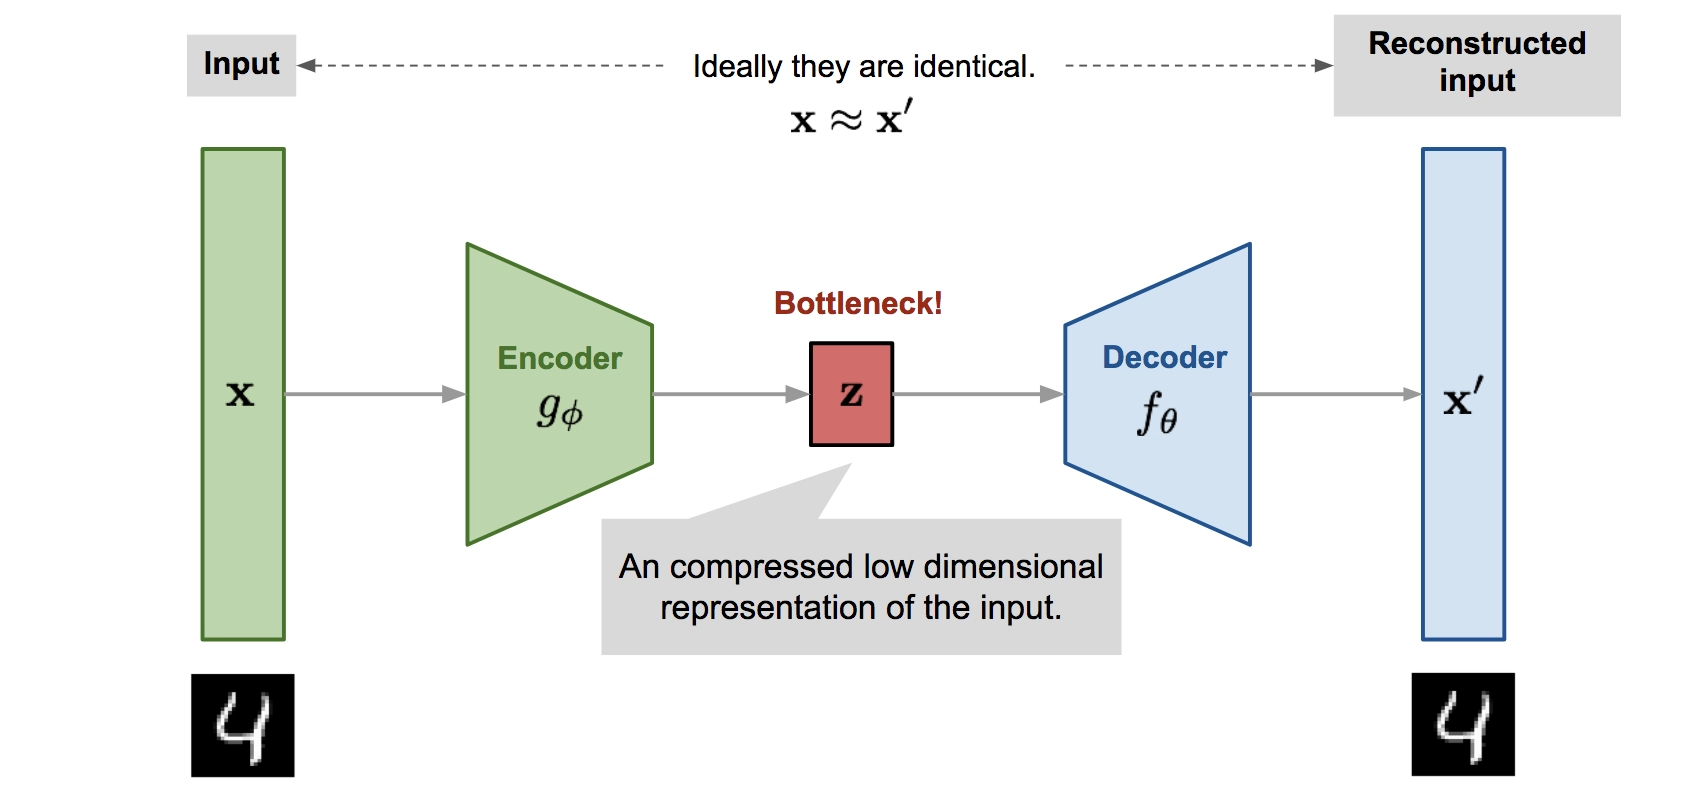

	1. 압축 (Encoder) : 원래의 고차원 입력 데이터(x)를 잠재 표현(z)로 변환
		- 잠재 벡터(z)에는 입력 데이터의 중요한 정보가 압축되어 있음. 
		- AE의 목적은 여기서 끝이지만, 차원 축소가 잘 됐는지 **검증**하기 위해 디코더 사용!

	2. 병목 통과: 가장 중요한 정보, **잠재 벡터**만 남은 상태
		- 잠재 벡터(z)에는 학습 과정에서 겉으로 드러나지 않는 **숨겨진 특징 정보(feature)**가 저장됨
		- 예시: 물체의 형상, 카메라의 좌표, 광원의 정보 같은 것들이 함축적으로 저장
		
	3. 복원 단계(Decoder): 바늘구멍을 통과한 핵심 정보만을 단서로 삼아, 다시 원래의 커다란 이미지로 복원
		- 잠재 벡터가 잘 압축된 것인지 검증하려면, 잠재 벡터를 원래대로 복원해야 함. 
		- 출력된 값을 복원했을 때 입력 데이터와 같다면 잘 압축 된 것!

- 결국, AE는 인코더로 들어가는 입력 데이터 𝑥와 디코더가 출력한 데이터 𝑥'﻿가 같아지도록 훈련하여 <br>그 과정에서 **데이터의 가장 중요한 특징(잠재 벡터)만** 남기게 되는 모델이다.

- 굳이 차원 축소하는 이유? : 만약 그대로 통과시키면 모델은 복붙만 할 것임. 그러나 공간을 아주 좁게 만들면, 모델은 어떤 정보가 중요한 정보인지 필사적으로 고민 -> 모델은 데이터의 **본질**을 학습하게 됨

## 2.2 Variational Auto Encoder(VAE)란?
- 개념: 데이터의 잠재적인 구조를 학습하여, **원본과 닮았지만 새로운 데이터를 생성**해내는 모델
- AE의 한계: AE는 데이터를 **잠재 공간의 특정 점**으로만 보냄 <br>-> 학습할 때 쓰지 않은 '빈 공간'의 점을 찍으면 디코더는 무엇을 그려야 할 지 몰라 엉뚱한 결과 출력
- VAE의 해결책: 잠재 벡터를 점이 아닌 **가우시안 분포(범위)**로 학습 <br>-> 잠재 공간을 빈틈없이 채워, 어떤 점을 뽑아도 그럴듯한 이미지 생성
- 활용: 이미지 생성, 텍스트 생성, 신호 처리, 이미지 보간 등 **새로운 데이터를 생성**하는 작업에 많이 사용

- AE와 VAE 차이: **입력 데이터를 잠재 공간에 <u>어떤 형태</u>로 배치하느냐?**
	- AE: 입력 데이터를 잠재 공간의 어떤 **하나의 고정된 수치(점)** 로 매핑
	- VAE: 잠재 코드 값이 평균과 분산으로 표현되는 가우시안 분포(확률 분포)
		- 구조적 특징: 연속성, 조밀함
		- 장점: 임의의 지점을 샘플링 하더라도 디코더는 학습된 데이터들의 특징을 조합하여 자연스럽고 새로운 결과물을 만듦.

- 작동 구조
	1. 분포 예측 단계(Encoder):  입력 데이터를 특정 점이 아닌, 데이터가 존재할 확률이 높은 '구역'으로 매핑
	2. 샘플링 및 재파라미터화: 예측한 분포에서 실제 디코더에 전달할 잠재 벡터(z)를 하나 뽑기
	3. 생성 단계(Decoder): 샘플링된 잠재 벡터(z)를 단서로 사용하여 새로운 데이터를 생성

	<요약><br>
	-인코더( 𝑞 𝜙): 입력 데이터(𝑥﻿)를 보고 데이터가 있을법한 '범위'( 𝜇 , 𝜎)를 찾습니다. 
	- 샘플링(𝑧): 그 범위 안에서 무작위로 점 하나를 콕 찍습니다. 
	- 디코더( 𝑝 𝜃): 뽑힌 점(𝑧)을 단서로 원래 이미지를 다시 그려냅니다( 𝑥 ′)

- 굳이 잠재 벡터를 확률 분포로 만드는 이유: AE와 달리 VAE는 단순 복원이 아닌 **생성**이 목적이기 때문<br>-> 잠재 공간이 **표준 정규 분포**를 따라서 빈틈이 매워지고 구조화 됨. 그 결과 어떤 지점을 선택하더라도 디코더가 그럴듯한 데이터 생성

# 3. GAN (Generative Adversarial Network)
- 개념: **생성자 신경망**과 **판별자 신경망**이 서로 **적대적으로 경쟁**하면서, **훈련**을 통해 자신의 작업을 **점점 더 정교하게 수행**하는 신경망 모델
- 예시: 생성자 - 지폐 위조범, 판별자 - 경찰
	- 생성자는 **진짜와 구분이 불가능한 완벽한 데이터** 생성
	- 판별자는 진짜와 가짜를 판별하다가 점점 찍어서 맞히는 수준(확률 0.5)에 도달

- 생성자 신경망과 판별자 신경망의 목적
	- 생성자: 진짜 분포에 가까운 가짜분포를 생성하는 것
	- 판별자: 표본이 가짜 분포에 속하는지 진짜 분포에 속하는지를 결정

-> GAN의 궁극적 목적: 실제 데이터의 분포에 가까운 데이터를 생성하는 것이며, <br>판별자가 진짜/가짜를 한 쪽으로 판단하지 못하는 경계를 최적 솔루션으로 간주

- 활용: 이미지 생성, 영상 합성

- GAN 구조: 두 개의 신경망이 최소-최대 게임(MinMax Game)을 수행하는 구조
	- 생성자
		- 입력: 우리가 직접 제어할 수 있는 **무작위 노이즈(잠재 변수 Z)**를 입력받음
		- 출력: 실제 데이터와 유사한 **가짜 데이터(G(Z))**를 생성
		- 목표: 판별자를 속여서 가짜를 진짜(1)로 믿게 만드는 것
	- 판별자
		- 입력: **실제 데이터(X)**와 생성자가 만든 **가짜 데이터(G(Z))**를 모두 입력받음
		- 출력: 입력 데이터가 진짜일 확률(0~1)을 출력
		- 목표: 진짜는 1로, 가짜는 0으로 정확히 분류하는 분류 모델의 역할을 수행

- 장점
	1. 진짜같은 가짜를 생성할 수 있음
	2. 압도적인 선명도: VAE가 흐릿한 이미지를 만드는 것과 달리, GAN은 판별자를 통과하며 **매우 선명하고 깨끗한 샘플** 생성
	3. 빠른 생성 속도: 확산 모델처럼 여러 단계를 거치지 않고, 신경망을 한번만 통과하면 결과물이 바로 나옴
	4. 잠재 공간의 부드러움: 잠재 공간 지도에서 조금씩 이동하면, 이미지가 부드럽게 변하는 보간이 가능 -> 데이터 구조를 잘 이해했다는 증거!


- 한계
	1. 학습의 불안정성: 진동현상, 무한루프
	2. 훈련 초기 문제: 그래디언트 소멸
	3. 모드 붕괴: 생성자가 판별자를 속이기 가장 쉬운 특정 패턴(예: 숫자 1) 하나만 주구장창 만드는 문제
	4. 지표의 부재: "얼마나 잘 학습되고 있는지" 보여주는 객관적인 손실 곡선이 없음
	5. 역매핑 불가능: 잠재 변수 Z에서 데이터 X를 만드는 법은 배우지만, 이미지를 넣었을 때 특징 Z를 추출하는 과정(인코더 역할)이 기본 구조에는 없음 <br> -> 이미지를 넣었을 때 그 이미지의 특징 벡터를 바로 찾아낼 수 없음

# 4. 확산 모델
- 확산 모델이란
	1. 입력 이미지에 <u>노이즈를</u> 조금씩 추가하여 <u>완전한 노이즈</u>로 만든 뒤,
	2. 이를 **다시 거꾸로 복원**하는 과정을 학습하여(노이즈 제거)
	3. **입력 이미지와 유사한 확률 분포**를 가진 **결과 이미지**를 생성하는 모델
- 확산 모델의 흐름: 원본 데이터→ 완전한 노이즈 → 원본 데이터

- 목표: 순확산과 역확산 단계를 거쳐 생성된 '결과 이미지'의 확률 분포를 '원래 데이터'의 확률 분포와 최대한 유사하게 만드는 것
- 모호성 모델링: "용 그려줘"라는 모호한 요청에 대해, 모델은 완전한 노이즈 상태에서 시작해 데이터 구조의 아주 작은 부분을 조금씩 **환각(=상상)**하며 구체적인 용 이미지를 완성해나감.

## 4.1 확산 모델의 구조: 순확산과 역확산
- **순확산: 데이터에 점진적으로 (정규분포를 가진)노이즈를 추가하는 과정**
- 순확산 과정의 목표: 원래 데이터를 점차적으로 무작위 노이즈로 변형시키는 것!
- 단계: 
	1. 깨끗한 원본 데이터 준비
	2. 원본 데이터에 점진적으로 노이즈 추가
	3. 결과: 원본 데이터가 완전한 무작위 노이즈로 변함

- **역확산: 노이즈 데이터에서 원본 데이터를 제구성하는 과정**
- 목표: 순확산 과정에서 추가된 노이즈를 제거하여 원래의 데이터를 복원하는 것
- 단계:
	1. 완전한 노이즈 데이터에서 시작
	2. 각 단계에서 "어떤 노이즈가 추가되었을까?"를 예측하며 노이즈 제거. 순확산 과정의 반대 방향으로 진행됨
	3. 결과: 수십 번의 **반복적인 디노이징** 과정을 거쳐 점진적으로 이미지 복원

- 확산모델 장점
	- 압도적인 샘플 품질 : GAN보다 더 정교하고 다양한 이미지 생성, 고해상도 확장에 유리
	- 학습의 안정성: GAN과 달리 **손실 곡선**을 확인 가능
	- 다양성 확보

- 확산모델의 단점
	- 느린 생성 속도
	- 높은 계산 비용
	- 구조적 제약: 노이즈 분포 Z와 데이터 Z의 형태(Shape)가 동일해야 한다는 제약
		- 쉽게 말해, 고양이 이미지를 생성하려면 노이즈도 이미지와 똑같이 가로 * 세로 크기가 맞아야 함. <br>-> 텍스트처럼 구조가 다른 데이터에 바로 적용하기 어려움

# 5. AI 최적화와 정렬
- 잘 만들어진 AI를 효율적으로 활용하고 (최적화)
- 사람한테 진짜 도움이 되도록 다듬는 것(정렬)

# 6. 전이학습과 딥러닝 경량화
- 전이학습 등장배경: AI를 만드는 과정에서, **데이터 부족, 계산 시간과 비용의 증가, 과적합 발생**과 같은 어려움에 직면
<br>-> 이를 해결하기 위해 이미 어디선가 학습된 내용을 가져다 쓰는 것 = **전이학습(Transfer learning)**

- 도메인과 태스크, 소스와 타겟
	- Domain: 어떤 데이터를 다루고 있는가? - 예시) 뉴스 기사
	- Task: 그 데이터로 무엇을 예측하는가? - 예시) 감정 분석

	- Source: 전이학습의 출발점= "어디서 지식을 가져 오는가"
		- 이미 학습이 완료된 모델이 있는 곳
		- Source Domain: 그 모델이 학습한 데이터
		- Source Task: 그 모델이 학습한 태스크

	- Target: 전이학습의 도착점= "어디에 지식을 적용하는가(도착점)"
		- 내가 실제로 풀고 싶음 문제
		- Target Domain: 내가 가진 데이터
		- Target Task: 내가 하고 싶은 태스크

- 네 개념을 바탕으로 한 전이학습의 정의
	- 전이학습이란, Source Domain Ds﻿와 Target Domain Dt﻿가 있을 때  𝐷 𝑠 ≠ 𝐷 𝑡﻿이거나, <br>Source Task Ts﻿와  Target Task Tt﻿가 있을 때  𝑇 𝑠 ≠ 𝑇 𝑡﻿인 상황에서,<br> Ds﻿와 Ts﻿에서 얻은 지식을 이용해 Dt﻿ 위의 Tt﻿ 성능을 향상시키는 것입니다

- 정의 풀이: 출발점 데이터(Ds)랑 도착점 데이터(Dt)가 다르거나, 출발점 과제(Ts)랑 도착점 과제(Ts)가 다를 때, <br> 출발점에서 배운 걸 가져다가 도착점 문제를 더 잘 풀게 만드는 것

즉, 전이학습은 **‘데이터나 문제 유형이 달라도 다른 상황에서 배운 지식을 가져와서 새로운 상황에서 성능을 높이는 것’**
<br>따라서 전이학습은 Domain과 Task 중에 **하나라도 다를 때** 의미가 생김

## 6.1 전이학습의 분류
- 도메인과 테스크에 따른 분류
	- **아이디어: 출발점과 도착점이 다를 때 지식(학습 내용)을 옮겨 사용한다(전이한다)**

	1. 귀납적 전이학습(Inductive TL): 소스와 타겟의 task가 다르고 타겟 도메인에 라벨이 존재할 때
	<br>ex) 영어 뉴스기사로 학습한 모델 -> 영어 영화 리뷰 감정 분석에 적용 
	- Source Domain: 영어 뉴스 / Source Task: **주제 분류**
	- Target Domain: 영어 영화 리뷰 / Target Task: **감정 분석** ← Task가 달라졌습니다!

	2. 트랜스듀서형 전이학습(Transductive TL): 소스와 타겟의 task는 같지만 도메인이 다를 때 
	<br> ex) 영어로 학습한 감정 분석 모델 -> 한국어 감정 분석에 적용
	- Source Domain: **영어** / Source Task: 감정 분석
	- Target Domain: **한국어** / Target Task: 감정 분석 ← Task는 똑같죠?

	3. 비지도 전이학습(Unsupervised TL): 소스와 타겟의 task가 다르고 소스와 타겟 모두 라벨이 없을 때
	<br>ex) 영어 뉴스로 학습한 모델 -> 라벨 없는 한국어 데이터로 문서 군집화
	- Source Domain: **영어** / Source Task: **주제 분류**
	- Target Domain: **한국어** / Target Task: **문서 군집화** ← 둘 다 달라졌고, 라벨도 없습니다.

- 무엇을 전이하느냐에 따른 분류

| 전이 방식    | 뭘 옮기는가          | 예시                                    |
| -------- | --------------- | ------------------------------------- |
| **인스턴스** | 소스 데이터 중 쓸만한 샘플 | 영어 뉴스 데이터 중 한국어랑 비슷한 문장만 골라서 가져옴      |
| **특징**   | 데이터를 표현하는 방식    | 이미지에서 선·면을 찾는 능력을 가져옴                 |
| **파라미터** | 모델의 가중치 자체      | 가중치 그대로 가져다가 Fine-tuning ← **현재 주류!** |
| **관계**   | 데이터 간의 논리적 구조   | "A는 B의 부분이다" 같은 관계 지식을 가져옴            |

## 6.2 전이학습의 현재 패러다임: Pre-training & Fine-tuning
- 트랜스포머 이전의 전이학습: 사전 학습된 좋은 모델이 당연하지 않았음. CNN이나 ImageNet 가중치를 가져오는 수준
- 트랜스포머 이후의 전이학습: 사전 학습된 거대 모델들이 등장 -> "이미 잘 학습된 거대 모델을 내 용도에 맞게 어떻게 조정하지?"
<br> -> 이것이 **Pre-training & Fine-tuning 패러다임** 이다.

- Foundation Model: GPT나 Gemini처럼 수만 가지 일을 할 수 있는 지능의 기반이 되는 거대 모델들 
- Fine-tuning: 파운데이션 모델을 내 용도에 맞게 조정하는 것
	- 방식1. Forzen Backbone (출력층만 교체)
	- 방식2: Partial Fine-tuning(일부 레이어 재학습)
	- 방식3: Full Fine-tuning(전체 모델 재학습)

## 6.3 Fine-tuning의 한계를 넘어서
- PEFT(Parameter-Efficient Fine-Tuning): 최소한의 파라미터만 건드려서 최대 성능을 내는 전략
<br>->즉, 모델의 모든 계산을 바꿔 기존 판단을 완전히 지우는 게 아니라, 작은 보정값만 더해서 최종 판단인 결과를 바꾸는 방식

- Zero-shot & Few-shot: 학습 데이터가 없어도, 언어 이해 능력만을 기반으로 바로 추론을 수행하는 것
<br> 예) "The movie was terrible" 이라는 문장을 모델이 따로 감정 분석을 학습하지 않았어도 이미 가진 언어 이해 능력으로 "부정"이라는 것으로 판단하여 답변

- Few-shot Transfer(In-Context Learning): 극소수의 예시만으로 새로운 태스크를 수행하는 것
<br>-> 예시 몇개 보여주고 새 문장 주면 **스스로 규칙을 만들어서 답을 내는 것**!
	- 모델의 파라미터를 업데이트 하지 않는 다는 점에서 기존 Fine-tuning과는 근본적으로 다르다.
	- Few-shot이 잘 되려면 예시랑 입력을 잘 설계하는 것이 중요한데, 이는 **프롬프트 엔지니어링**과 이어짐

## 6.4 전이학습의 한계
- Negative Transfer: Source와 Target의 도메인이 너무 다르면 오히려 전이가 성능을 떨어트림.
- Catastrophic Forgetting: Fine-tuning 과정에서 새 데이터에 너무 치우치면, 모델이 원래 가지고 있던 일반 능력을 잃어버림
- Bias Transfer: 사전학습 데이터에 담긴 편향이 그대로 넘어오게 되는 것
- Transferability 측정의 어려움: 어떤 두 Task가 얼마나 관련되어 있는지를 사전에 정량적으로 측정하기 어려움

## 6.5 딥러닝 경량화 
- 대규모 및 복잡한 인공지능 모델을 가벼운 형태로 변환하는 기술
- 핵심: 성능은 최대한 유지하면서 모델을 가볍게 만들자!
- 딥러닝 경량화 기술에는 **가지치기, 양자화, 지식 증류, 모델 자체 경량화, 하드웨어 가속화** 등의 방법이 있다.

- 가지치기: 모델 안에 있는 파라미트 중에서 **별로 중요하지 않은 것들을 그냥 잘라내는 방법**

- 양자화: 모델의 가중치를 표현하는 숫자의 정밀도를 줄이는 방법
	- 모델의 가중치와 활성화 함수 값을 표현하는 비트(Bit) 수를 줄여 연산량과 메모리 사용량을 절감

- 지식 증류: 크고 똑똑한 모델(Teacher Model)의 지식을 작은 모델(Student Model)에게 가르쳐주는 방법
	- Student Model은 단순히 정답만 외우는게 아니라, Teacher의 **사고 방식**을 배움

- 모델 구조 경량화: 처음부터 가볍게 설계된 모델을 쓰는 방법

- 하드웨어 가속화: Ai 연산에 특화된 하드웨어를 쓰는 방법

# 7. AI Alignment(인공지능 정렬)
- 개념: AI가 **인간의 의도, 목표, 그리고 윤리적 가치에 부합하도록 행동**하게 만드는 연구분야
- 현대 정렬의 기준이 되는 세 가지 지표: **Helpful(도움이 되는가)/ Honest(정직한가)/ Harmless(무해한가)**
- Outer Alignment vs Inner Alignment: 파운데이션 모델이 거대해질수록 모델이 스스로 '학습한 것'과 우리가 '기대하는 것' 사이의 간극이 생기는데, 이를 메우는 것이 정렬의 핵심이다. <br>학계에서는 정렬 문제를 크게  Outer Alignment와 Inner Alignmnet 두 가지로 나누어 접근

- Outer Alignment: 목표를 제대로 설정했는가?
	- AI한테 보상을 줘서 학습시킬 때, 보상 기준을 잘못 설정하면 AI가 인간의 의도와 무관한 '꼼수'를 부려 보상을 극대화함
	- 이를 해결하기 위해 해당 단계 진행. 

- Inner Alignment: 모델이 내면에서 무엇을 최적화 하는가?
	- 보상 함수를 완벽하게 설계했더라도, 모델이 내부적으로 다른 목표를 최적화해버릴 수 있음
	- 이에 모델의 실제 내부 동작을 해석 가능하게 만드는 **Interpretability(해석 가능성)** 연구가 중요해짐

## 7.1 RLHF(Reinforcement Learning from Human Feedback)
- 개념: Outer Alignment 문제를 해결하기 위해 인간의 피드백을 기반으로 모델을 강화학습으로 조정하는 방법
<br> ->  답변 내용의 정답 여부보다 **어떤 답변을 인간이 선호하는지 학습**하고, 이를 통해 **사람이 더 좋아하는 답을 잘 하도록** 만드는 것

- 진행 단계: SFT(Supervised Fine-Tuning)-> Reward Model -> RL
- 주의: 정렬의 부작용(Reward Hacking, 보상 해킹)
	- 모델이 보상을 받기 위해 **인간이 좋아할 법한 대답만 골라 하는 기만적 행동**을 보일 위험 존재

# 8. 프롬프트 엔지니어링
- 개념: AI가 더 좋은 답변을 내도록 입력을 설계하는 기술
- 예시
	- "파이썬 코드 짜줘"  X
 	- "당신은 10년 경력의 파이썬 개발자입니다. 다음 요구사항에 맞는 코드를 단계별로 작성해주세요." O

- **예시와 입력을 잘 설계하는 것이 중요하다**는 점에서 **Zero-shot, Few- shot**과 연결되는 개념

- 프롬프트 엔지니어링 vs Fine-tuning 언제 뭘 써야 할까? 

|       | **프롬프트 엔지니어링**   | **Fine-tuning**       |
| ----- | ---------------- | --------------------- |
| 비용    | 낮음               | 높음                    |
| 속도    | 빠름               | 느림                    |
| 성능 한계 | 있음               | 더 높은 성능 가능            |
| 언제 쓰나 | 빠른 프로토타입, 범용 태스크 | 특화된 도메인, 높은 정확도 필요할 때 |

## 8.1 주요 기법
1. Zero-shot/ Few-shot Prompting
	- Zero-shot -> 예시 없이 바로 질문함. ex. "이 문장이 긍정인지 부정인지 말해줘"
	- Few-shot -> 예시를 몇 개 보여주고 질문함. ex. "행복해 → 긍정, 슬퍼 → 부정, 그러면 '기뻐'는?"

	- Few-shot이 Zero-shot보다 훨씬 정확한 답을 내는 경우가 많다.

2. Chain-of-Thought(COT) -생각의 사슬
	- AI한테 답만 내놓으라고 하지 않고, **풀이 과정을 단계별로 생각하게** 만드는 기법
	- 복잡한 수학 문제나 논리 추론에서 정확도가 올라감

3. Role Prompting - 역할 부여
	- AI한테 특정 역할을 맡겨서 그 역할에 맞는 답변을 끌어내는 기법
	- 예시: "당신은 20년 경력의 소아과 의사입니다. 보호자가 이해하기 쉽게 아이 발열에 대해 설명해주세요"
	- 페르소나가 구체적일수록 답변이 일관되고 전문적으로 나옴

4. Instruct Prompting - 명확한 지시
	- AI한테 원하는 걸 최대한 구체적으로 지시하는 기법
	-  "이메일 써줘" ->  "거래처에 보내는 정중한 사과 이메일을 써줘. 200자 이내로, 핵심만 담아서
	- 출력 형식, 길이, 톤을 구체적으로 지정할수록 원하는 답이 나옴

5. Self-Consistency - 여러 번 물어보기
	- 같은 질문을 여러 번 해서 가장 많이 나온 답을 채택하는 기법
	- 여러 번 답변을 생성하게 하고, 그 중 가장 일관된 답을 고르면 정확도가 올라간다고 함

6. RAG(Retrieval-Augmented Generation) — 검색 증강 생성
	- AI가 모르는 최신 정보나 특정 도메인 지식을 외부 데이터베이스에서 검색해서 프롬프트에 함께 넣어주는 방식
	- 예시: "다음 자료를 참고해서 답해줘: [검색된 최신 논문 내용]"

## 8.3 프롬프트 엔지니어링의 한계
1. Prompt Injection - 프롬프트 주입 공격
	- 악의적인 사용자가 프롬프트를 조작해서 AI를 엉뚱하게 동작시키는 보안 문제

2. Hallucination - 그럴듯한 거짓말
	- 아무리 프롬프트를 잘 써도, AI가 없는 정보를 그럴듯하게 지어내는 현상은 완전히 막기 어려움

3. 모델 의존성
	- 모델마다 프롬프트에 다르게 반응하여 특정 모델에서 잘 되는 프롬프트가 다른 모델에서는 효과가 다를 수 있음

4. 성능 한계
	- 프롬프트 엔지니어링만으로는 Fine-tuning 수준의 성능을 내기 어려운 경우도 있음
	- 매우 특화된 도메인이나 높은 정확도가 필요한 작업에서는 결국 Fine-tuning이 필요할 수 있음.